####Exploratory Data Analysis (EDA) on Cardiotocographic Dataset###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path= "Cardiotocographic.csv"
df = pd.read_csv(file_path)

In [3]:
print(df.head())

           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency  NSP  
0   2.4   64.0  0.999926  2.0  
1  10.4  130.0  0.000000  1.0  
2  13.4  130.0  0.000000  1.0  
3  23.0  117.0  1.000000  1.0  
4  19.9  117.0  1.000000  1.0  


In [4]:
print('Shape of Dataset:', df.shape)

Shape of Dataset: (2126, 14)


In [5]:
print('\nColumns in Dataset:\n')
print(df.columns)


Columns in Dataset:

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')


In [6]:
print('\nDataset Information:\n')
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None


In [7]:
print(df.isnull().sum())

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [8]:
# Fill missing numerical values using mean
for column in df.columns:
    if df[column].dtype != 'object':
        df[column].fillna(df[column].mean(), inplace=True)

In [9]:
# Count duplicate rows
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 2


In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [11]:
# Statistical summary
print(df.describe())

                LB           AC           FM           UC           DL  \
count  2124.000000  2124.000000  2124.000000  2124.000000  2124.000000   
mean    133.342039     0.003220     0.009904     0.004394     0.001897   
std      11.212396     0.004371     0.067571     0.003340     0.003344   
min      51.842487    -0.019284    -0.480634    -0.014925    -0.015393   
25%     126.000000     0.000000     0.000000     0.001858     0.000000   
50%     133.000000     0.001668     0.000000     0.004486     0.000000   
75%     140.000000     0.005612     0.002568     0.006536     0.003292   
max     214.000000     0.038567     0.961268     0.030002     0.030769   

                DS           DP         ASTV         MSTV         ALTV  \
count  2124.000000  2124.000000  2124.000000  2124.000000  2124.000000   
mean      0.000003     0.000175    47.012459     1.364345    10.295650   
std       0.000141     0.000836    18.812403     1.174084    21.212676   
min      -0.001353    -0.005348   -63

####Measure of Central Tendency####

In [12]:
# Mean and Median
mean_values = df.mean()
median_values = df.median()

print('Mean Values:\n', mean_values)
print('\nMedian Values:\n', median_values)

Mean Values:
 LB          133.342039
AC            0.003220
FM            0.009904
UC            0.004394
DL            0.001897
DS            0.000003
DP            0.000175
ASTV         47.012459
MSTV          1.364345
ALTV         10.295650
MLTV          8.280589
Width        70.460738
Tendency      0.316669
NSP           1.304794
dtype: float64

Median Values:
 LB          133.000000
AC            0.001668
FM            0.000000
UC            0.004486
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.500000
Width        68.000000
Tendency      0.000000
NSP           1.000000
dtype: float64


####Interquartile Range####

In [13]:
# Calculated IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

print('Interquartile Range:\n')
print(IQR)

Interquartile Range:

LB          14.000000
AC           0.005612
FM           0.002568
UC           0.004678
DL           0.003292
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.200000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64


####Outlier Detection Using Boxplot####

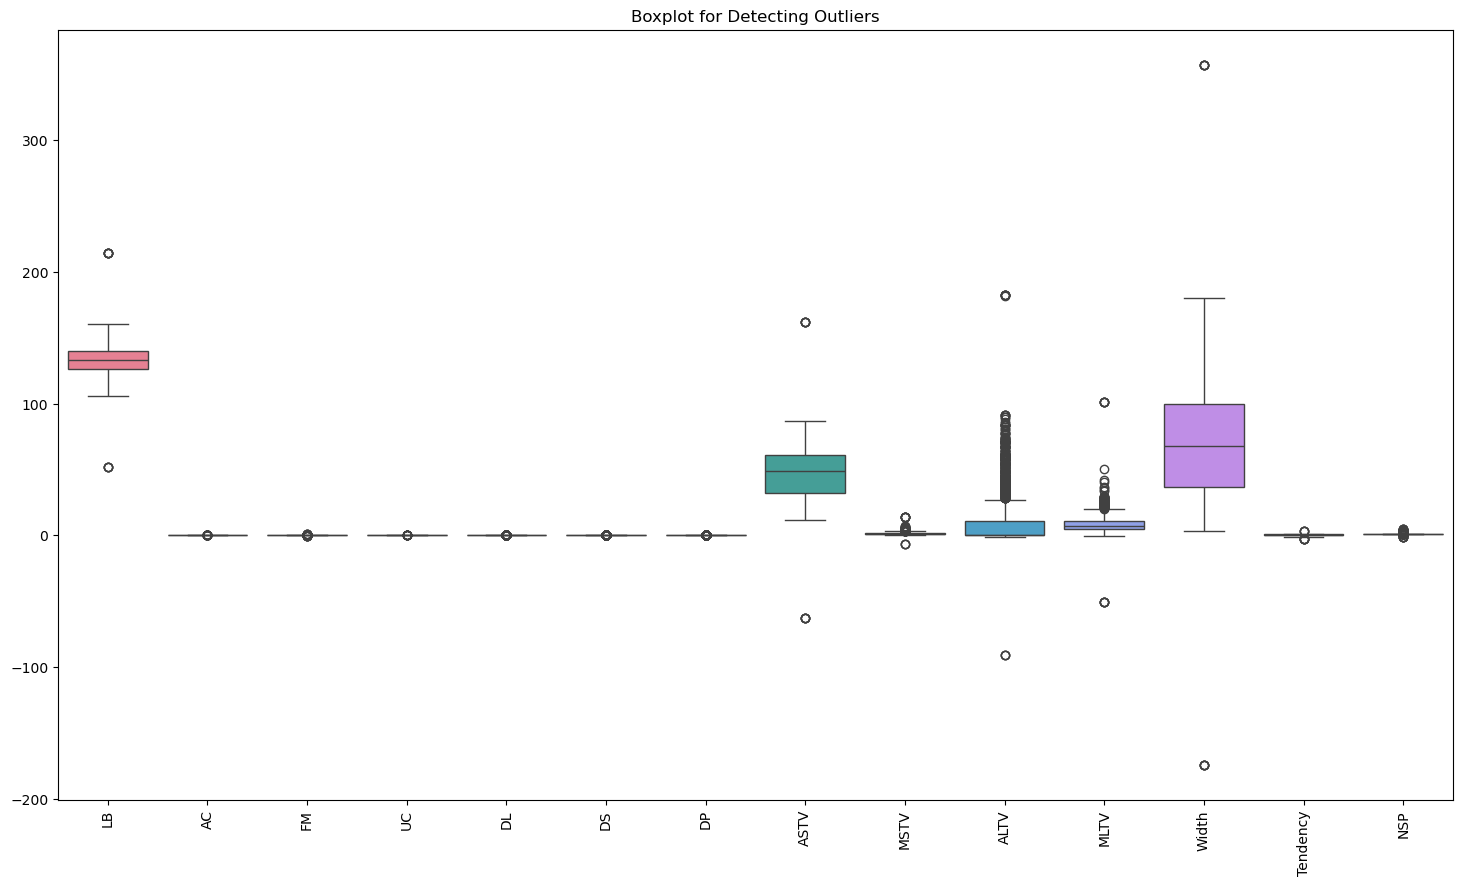

In [14]:
# Boxplot for all numerical features
plt.figure(figsize=(18,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplot for Detecting Outliers')
plt.show()

####Histograms####

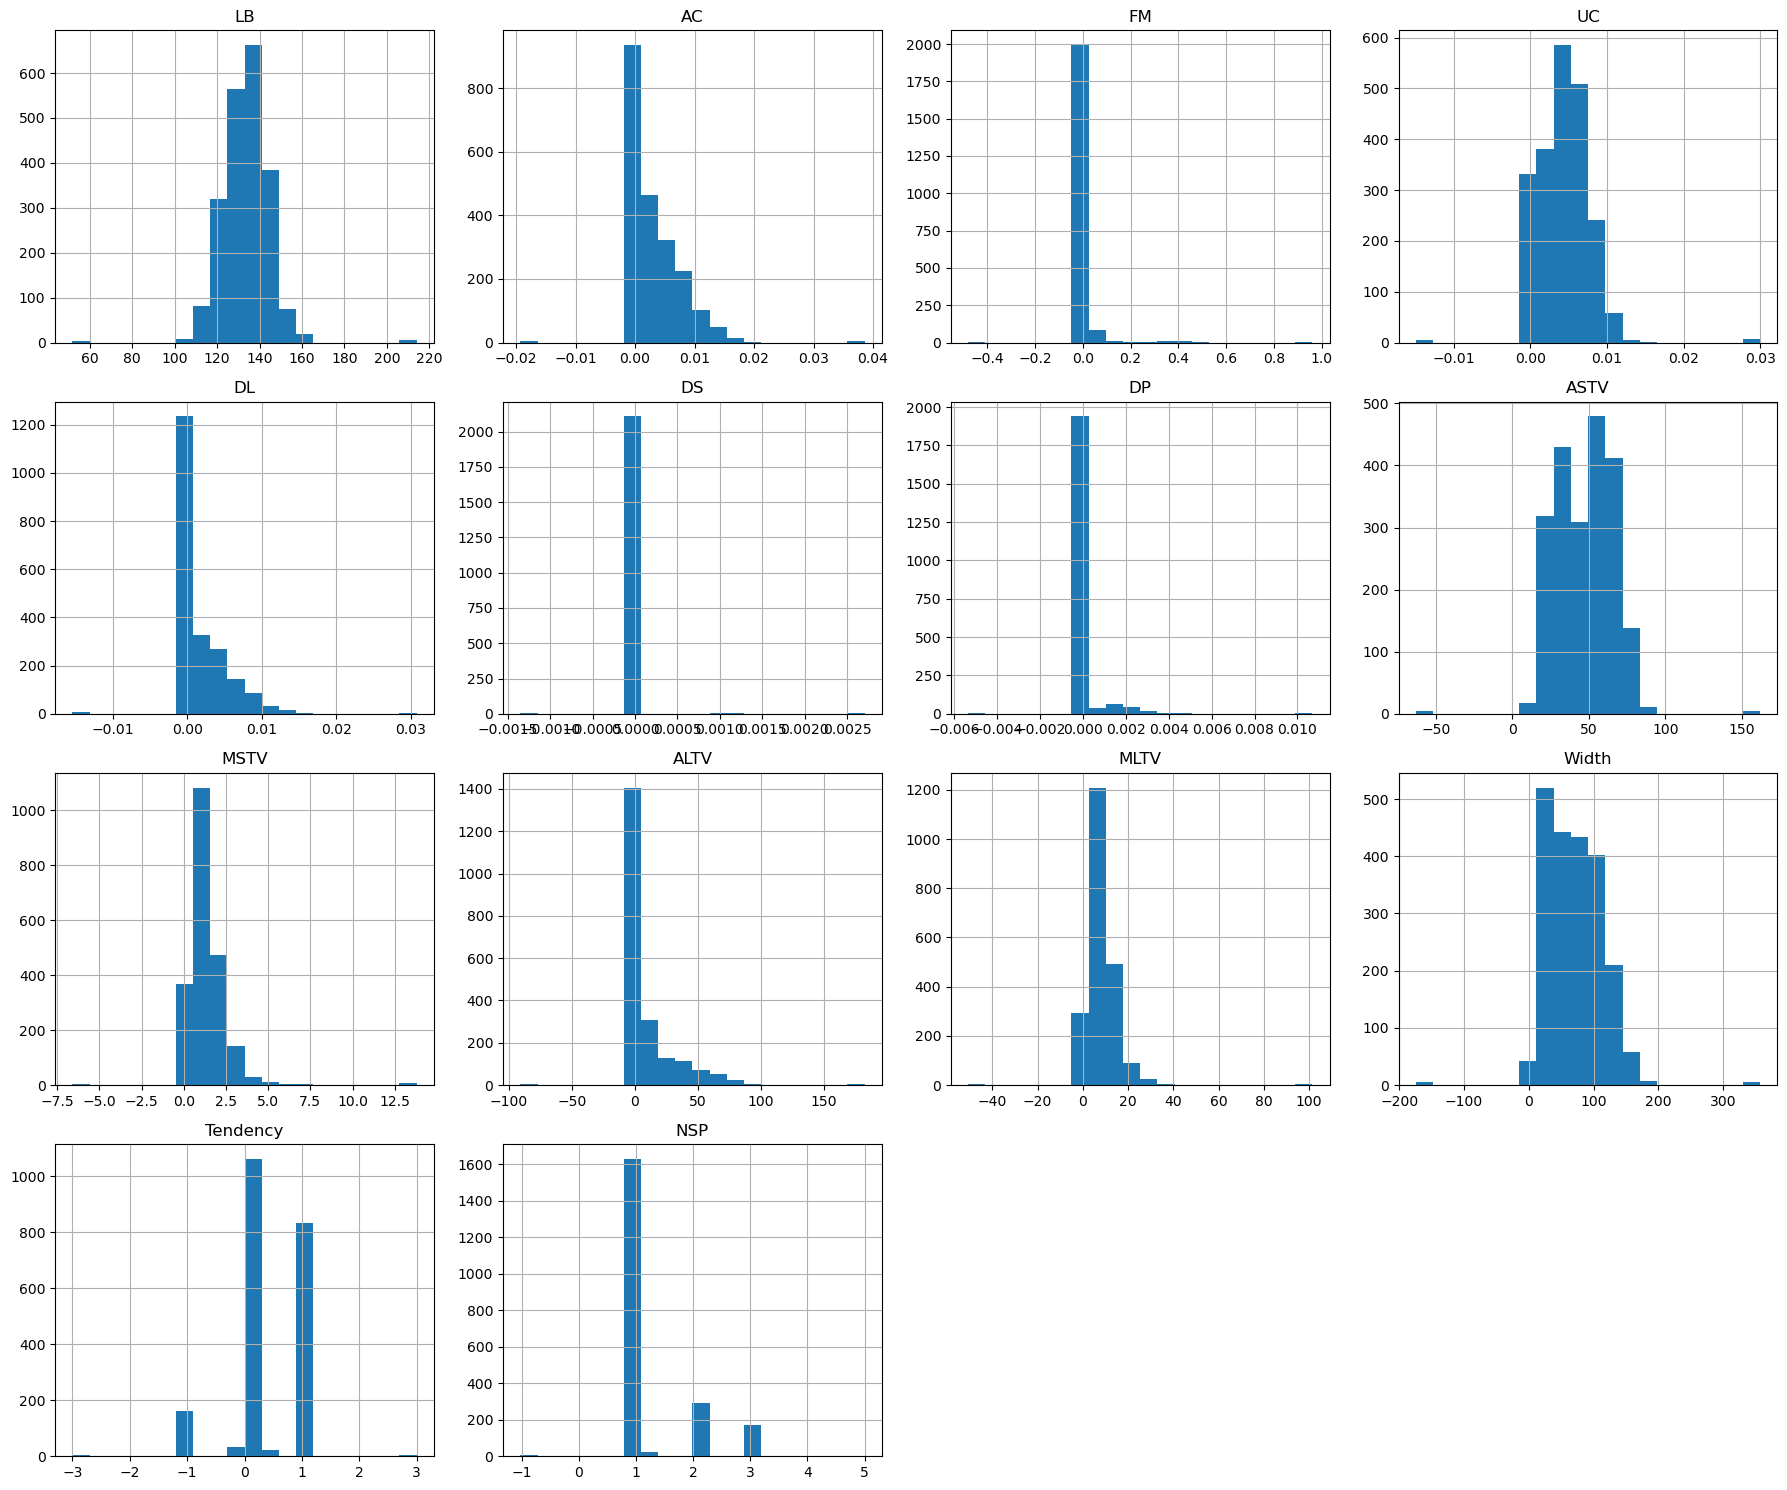

In [15]:
# Histograms for all columns
df.hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

####Correlation Heatmap####

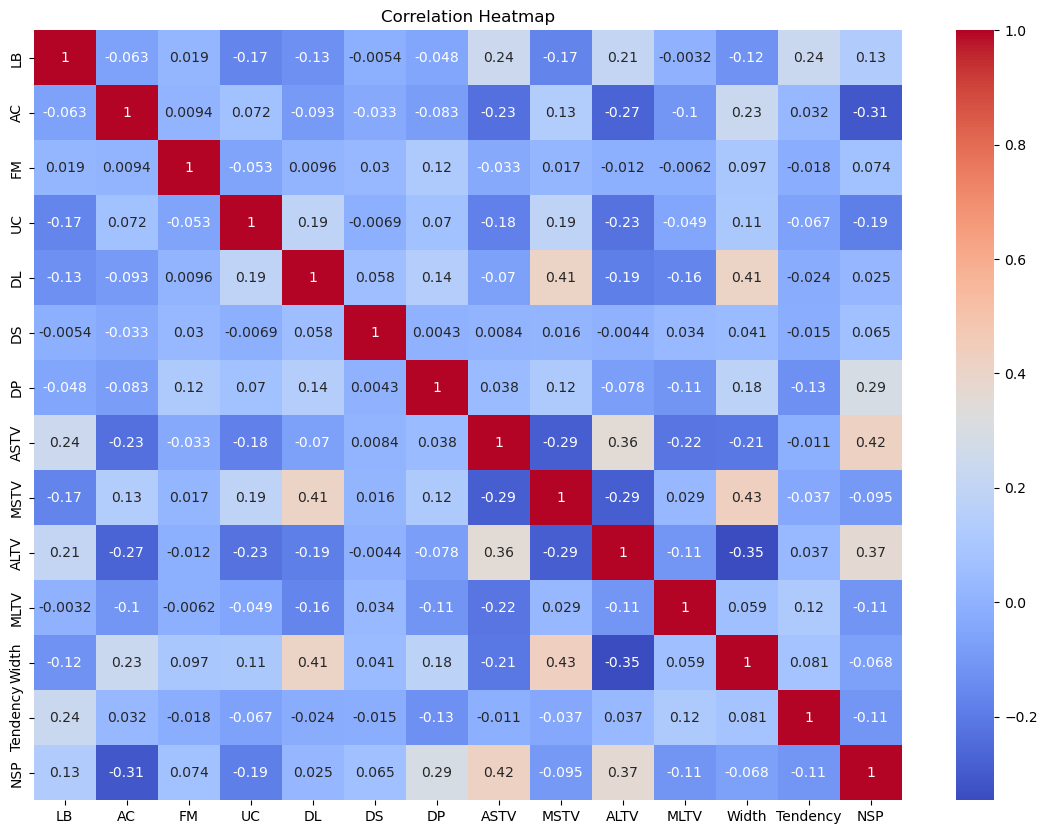

In [16]:
# Correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

####Scatter Plot Analysis####

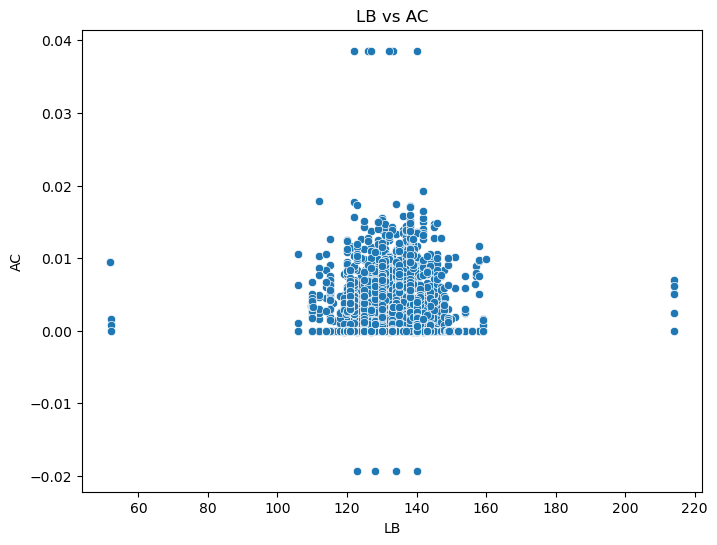

In [17]:
# Scatter plot between LB and AC
plt.figure(figsize=(8,6))
sns.scatterplot(x='LB', y='AC', data=df)
plt.title('LB vs AC')
plt.show()

###Pair Plot###

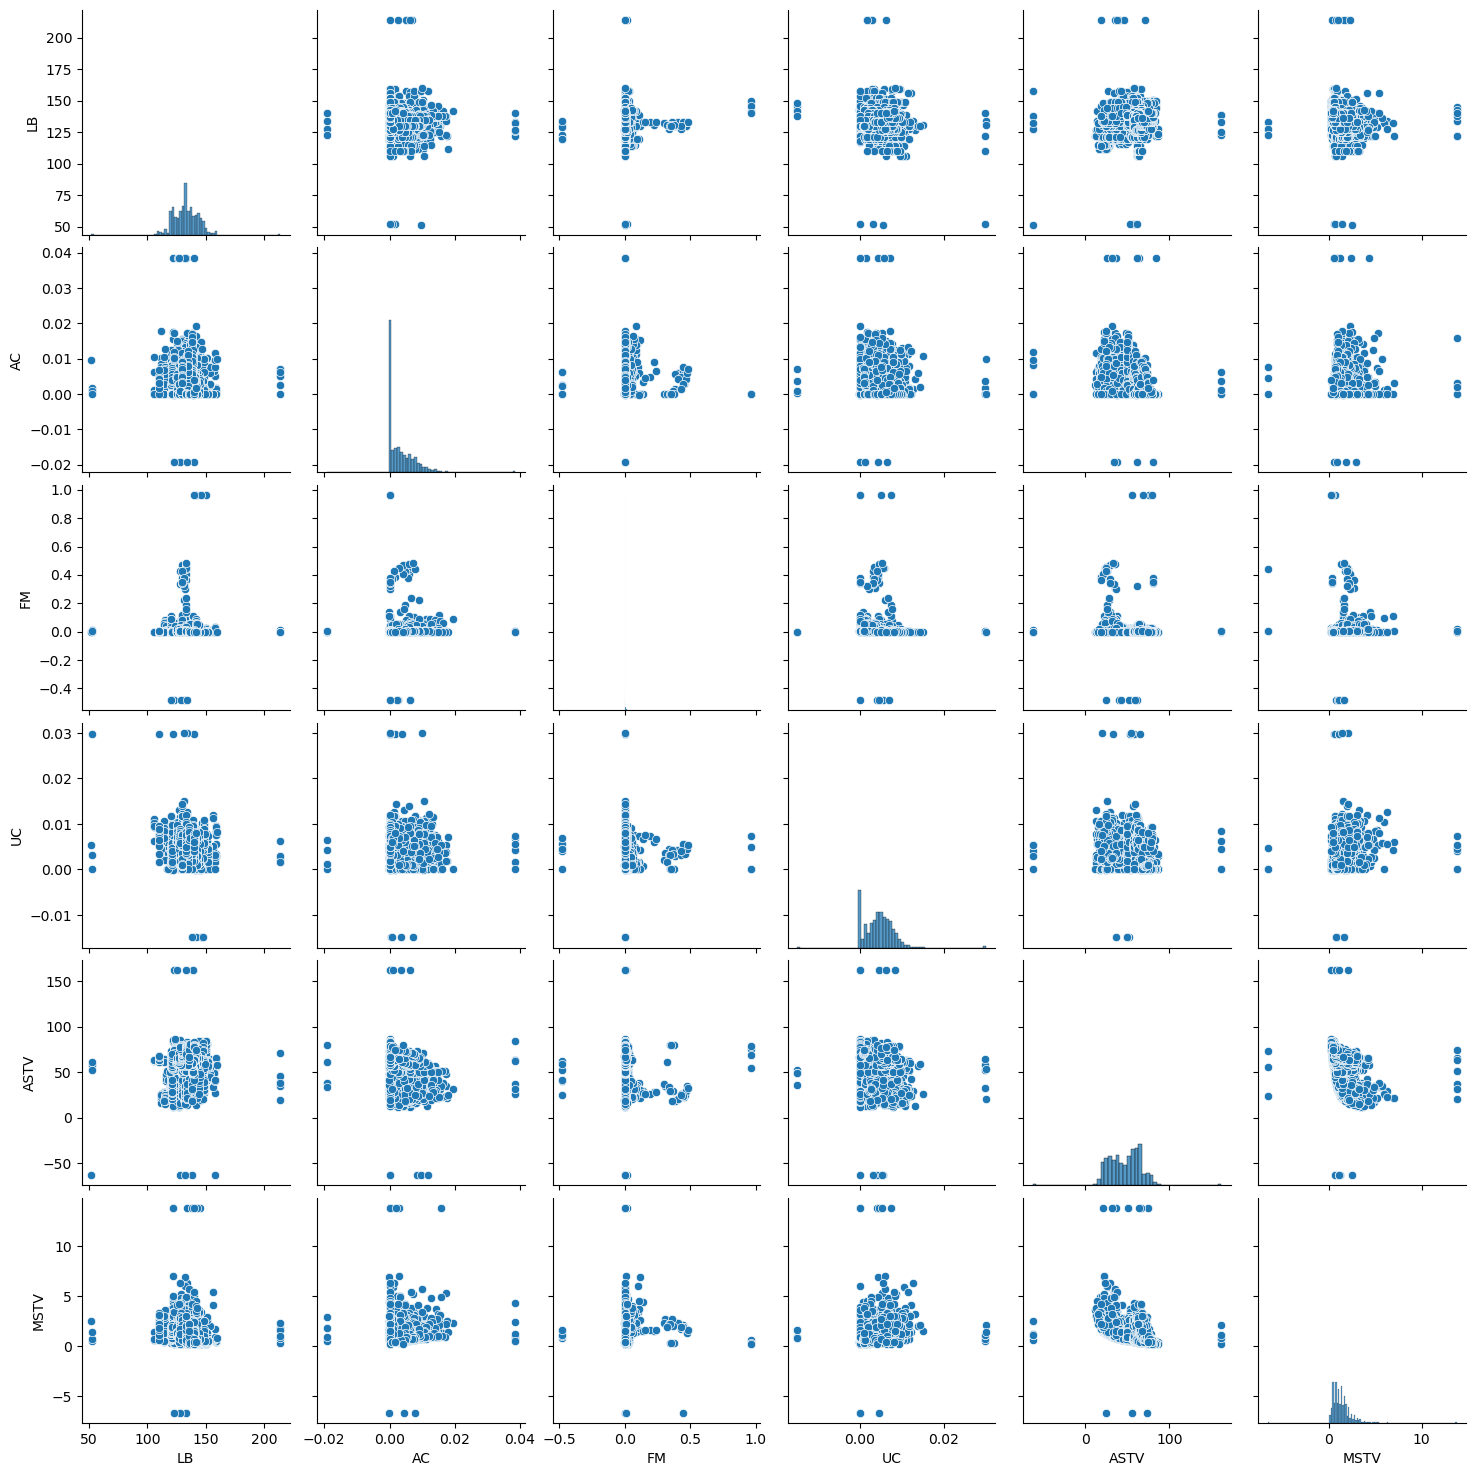

In [18]:
# Pairplot of selected features
selected_features = ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV']

sns.pairplot(df[selected_features])
plt.show()

###Violin Plot####

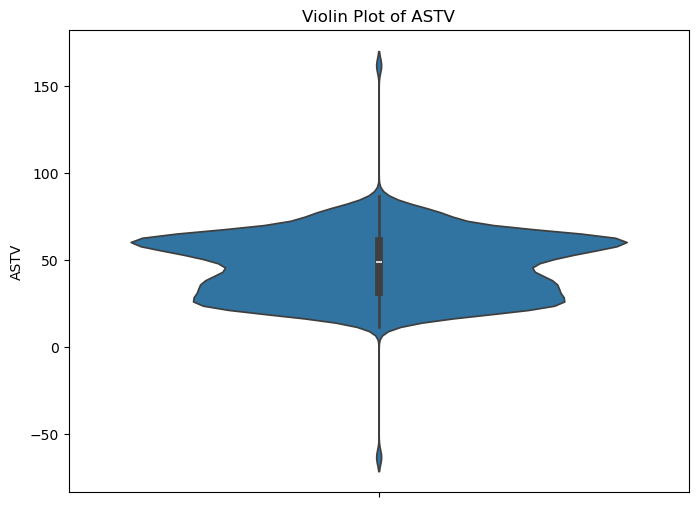

In [23]:
# Violin plot for ASTV
plt.figure(figsize=(8,6))
sns.violinplot(y=df['ASTV'])
plt.title('Violin Plot of ASTV')
plt.show()

#####Count Plot for Target#####

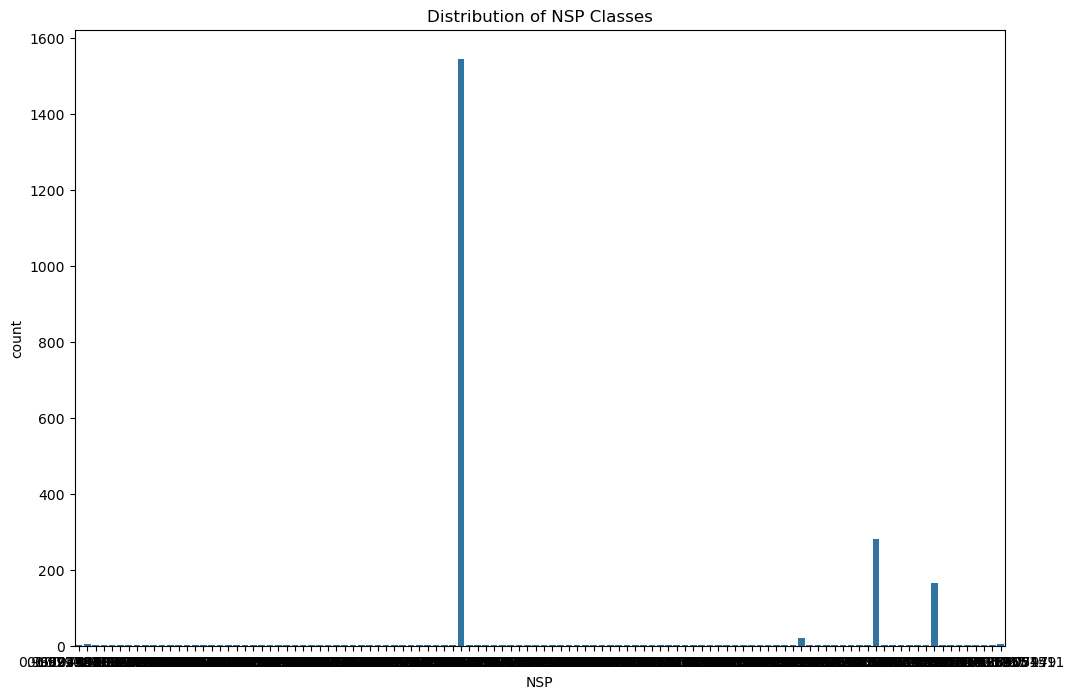

In [20]:
# Count plot for NSP
plt.figure(figsize=(12,8))
sns.countplot(x='NSP', data=df)
plt.title('Distribution of NSP Classes')
plt.show()

####Pattern Recognition and Insights#####

####Conclusion####